# Heston vs Bates — NN Hedging Error Comparison (Calibrated Parameters)

Trains two `HestonHedgeNet` networks using the **calibrated parameters from Table 4.1** of the thesis (Kozyra 2006 calibration), then overlays the resulting P&L distributions for a fair apples-to-apples comparison.

Both models share the same hedge instruments (stock + variance swap), so `HestonHedgeNet`, `HestonCVaRLoss`, and `heston_trainer.train()` are reused unchanged for both.

| Model  | ν₀     | κ      | θ      | ξ      | ρ       | jumps |
|--------|--------|--------|--------|--------|---------|-------|
| Heston | 0.0654 | 0.6067 | 0.0707 | 0.2928 | −0.7571 | —     |
| Bates  | 0.0574 | 0.4963 | 0.0650 | 0.2286 | −0.9900 | μ_J=0.1791, σ_J=0.1346, λ=0.1382 |

* **α = 0.5** (ES₀.₅ loss) for both.
* Both networks are trained locally here and saved to `results/` (skipped on re-run if already saved).

In [ ]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from src.heston_simulator import HestonParams, simulate as heston_simulate
from src.bates_simulator import BatesParams, BatesSimulator
from src.hedging.hedge_network import HestonHedgeNet
from src.hedging.loss import HestonCVaRLoss
from src.hedging.heston_trainer import train

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})
RESULTS_DIR = Path('..') / 'results'

K     = 100.0
N     = 30
dt    = 1 / 365
ALPHA = 0.5

## 1 — Heston network (calibrated parameters, train locally)

In [41]:
HESTON_NET_PATH = RESULTS_DIR / 'heston_calib_ES05_network.pt'
HESTON_LOG_PATH = RESULTS_DIR / 'heston_calib_ES05_log.pt'

# Calibrated Heston parameters — Table 4.1 (Kozyra 2006)
heston_calib_params = HestonParams(
    S0=100.0,
    v0=0.0654,
    kappa=0.6067,
    theta=0.0707,
    xi=0.2928,
    rho=-0.7571,
    T=N * dt,
    N=N,
    M=100_000,
)

if HESTON_NET_PATH.exists():
    print('Calibrated Heston weights already exist — skipping simulation and training.')
    heston_log      = torch.load(HESTON_LOG_PATH, weights_only=False)
    vp_scale_heston = heston_log['vp_scale']
    p0_heston       = heston_log['p0']
    net_heston = HestonHedgeNet(N=N, width=20)
    net_heston.load_state_dict(torch.load(HESTON_NET_PATH, weights_only=True))
    net_heston.eval()
    print(f'Heston vp_scale : {vp_scale_heston:.4f}')
    print(f'Heston p0       : {p0_heston:.4f}')
else:
    print('Simulating 100 K calibrated Heston training paths ...')
    S_h, V_h, VP_h = heston_simulate(heston_calib_params, seed=19)
    print(f'  S: {S_h.shape}  V: {V_h.shape}  VarPrice: {VP_h.shape}')

    vp_scale_heston = 1.0 / float(VP_h[:, 0].mean())
    VP_h_scaled     = VP_h * vp_scale_heston
    print(f'  Heston vp_scale: {vp_scale_heston:.4f}')

    with torch.no_grad():
        p0_heston = float(torch.clamp(S_h[:, -1] - K, min=0.0).mean())
    print(f'  Heston call price (MC): {p0_heston:.4f}')

    net_heston = HestonHedgeNet(N=N, width=20)
    loss_fn_h  = HestonCVaRLoss(K=K, alpha=ALPHA)

    # lr=5e-3: the calibrated params (ξ=0.2928, near Feller) produce a much smoother
    # loss landscape than the He et al. params (ξ=2.0) that train_heston.py was
    # designed for.  The higher lr=5e-2 overshoots on the calibrated problem;
    # 5e-3 matches what train_adv_heston.py uses for HestonHedgeNet.
    print(f'Training Heston ES_{ALPHA} network (700 epochs, lr=5e-3) ...')
    losses_h, p0_h_tensor = train(
        net_heston,
        S_h,
        V_h,
        VP_h_scaled,
        loss_fn_h,
        p0_init   = p0_heston,
        n_epochs  = 700,
        batch_size= 10_000,
        lr        = 5e-3,   # lower than He et al. (5e-2) — calibrated params are smoother
        log_every = 100,
    )
    p0_heston    = p0_h_tensor.item()
    losses_heston = losses_h
    net_heston.eval()

    torch.save(net_heston.cpu().state_dict(), HESTON_NET_PATH)
    torch.save(
        {'losses': losses_h, 'p0': p0_heston, 'alpha': ALPHA,
         'params': vars(heston_calib_params), 'vp_scale': vp_scale_heston},
        HESTON_LOG_PATH,
    )
    print(f'Heston network saved.  Final p0 = {p0_heston:.4f}')

Simulating 100 K calibrated Heston training paths ...
  S: torch.Size([100000, 31])  V: torch.Size([100000, 31])  VarPrice: torch.Size([100000, 31])
  Heston vp_scale: 185.6657
  Heston call price (MC): 2.9002
Training Heston ES_0.5 network (700 epochs, lr=5e-3) ...
epoch    0  loss=6.824783  p0=2.8952
epoch  100  loss=3.290521  p0=2.8747
epoch  200  loss=3.265266  p0=2.8714
epoch  300  loss=3.256648  p0=2.8789
epoch  400  loss=3.244925  p0=2.8792
epoch  500  loss=3.242197  p0=2.8792
epoch  600  loss=3.245056  p0=2.8794
epoch  699  loss=3.249836  p0=2.8793
Heston network saved.  Final p0 = 2.8793


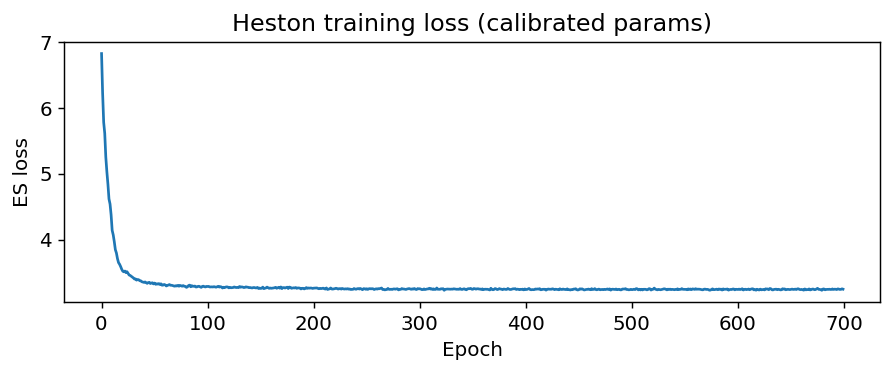

First loss: 6.8248  →  Last loss: 3.2498


In [42]:
# Training loss curve — verify convergence (only plotted when trained this session)
if 'losses_heston' in dir():
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(losses_heston)
    ax.set_xlabel('Epoch'); ax.set_ylabel('ES loss')
    ax.set_title('Heston training loss (calibrated params)')
    plt.tight_layout(); plt.show()
    print(f'First loss: {losses_heston[0]:.4f}  →  Last loss: {losses_heston[-1]:.4f}')

## 2 — Bates network (calibrated parameters, train locally)

Uses the same `HestonHedgeNet` architecture and `heston_trainer.train()` — both Bates and Heston share stock + variance-swap as hedge instruments, so no new code is needed.

In [43]:
BATES_NET_PATH = RESULTS_DIR / 'bates_ES05_network.pt'
BATES_LOG_PATH = RESULTS_DIR / 'bates_ES05_log.pt'

bates_params = BatesParams(
    S0=100.0,
    v0=0.0574,
    kappa=0.4963,
    theta=0.0650,
    xi=0.2286,
    rho=-0.990,
    mu_J=0.1791,
    sigma_J=0.1346,
    lam=0.1382,
    T=N * dt,
    N=N,
    M=100_000,
)

if BATES_NET_PATH.exists():
    print('Bates weights already exist — skipping simulation and training.')
    bates_log       = torch.load(BATES_LOG_PATH, weights_only=False)
    vp_scale_bates  = bates_log['vp_scale']
    p0_bates        = bates_log['p0']
    net_bates = HestonHedgeNet(N=N, width=20)
    net_bates.load_state_dict(torch.load(BATES_NET_PATH, weights_only=True))
    net_bates.eval()
    print(f'Bates vp_scale : {vp_scale_bates:.4f}')
    print(f'Bates p0       : {p0_bates:.4f}')
else:
    print('Simulating 100 K Bates training paths ...')
    sim   = BatesSimulator(bates_params)
    S_b, V_b, VP_b = sim.simulate(seed=42)
    print(f'  S: {S_b.shape}  V: {V_b.shape}  VarPrice: {VP_b.shape}')

    vp_scale_bates = 1.0 / float(VP_b[:, 0].mean())
    VP_b_scaled    = VP_b * vp_scale_bates
    print(f'  Bates vp_scale: {vp_scale_bates:.4f}')

    with torch.no_grad():
        p0_bates = float(torch.clamp(S_b[:, -1] - K, min=0.0).mean())
    print(f'  Bates call price (MC): {p0_bates:.4f}')

Bates weights already exist — skipping simulation and training.
Bates vp_scale : 211.3996
Bates p0       : 2.7197


In [44]:
if not BATES_NET_PATH.exists():
    net_bates = HestonHedgeNet(N=N, width=20)
    loss_fn   = HestonCVaRLoss(K=K, alpha=ALPHA)

    print(f'Training Bates ES_{ALPHA} network (700 epochs) ...')
    losses_b, p0_b_tensor = train(
        net_bates,
        S_b,
        V_b,
        VP_b_scaled,
        loss_fn,
        p0_init   = p0_bates,
        n_epochs  = 700,
        batch_size= 10_000,
        lr        = 5e-2,
        log_every = 100,
    )
    p0_bates = p0_b_tensor.item()
    net_bates.eval()

    torch.save(net_bates.cpu().state_dict(), BATES_NET_PATH)
    torch.save(
        {'losses': losses_b, 'p0': p0_bates, 'alpha': ALPHA,
         'params': vars(bates_params), 'vp_scale': vp_scale_bates},
        BATES_LOG_PATH,
    )
    print(f'Bates network saved.  Final p0 = {p0_bates:.4f}')

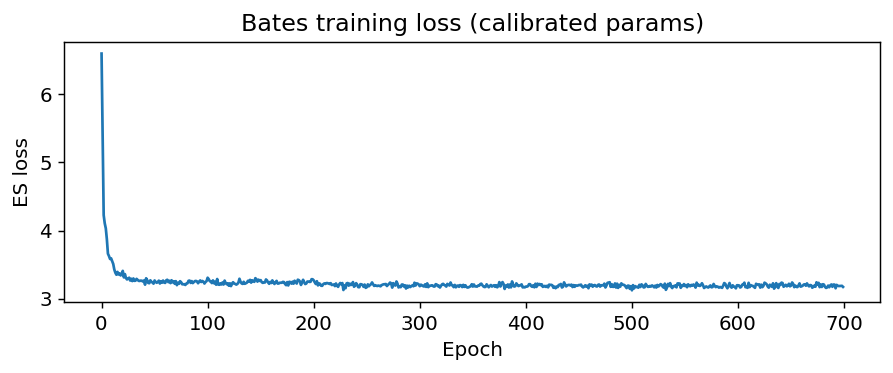

First loss: 6.5912  →  Last loss: 3.1749


In [45]:
# Training loss curve — verify convergence (only plotted when trained this session)
if 'losses_b' in dir():
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(losses_b)
    ax.set_xlabel('Epoch'); ax.set_ylabel('ES loss')
    ax.set_title('Bates training loss (calibrated params)')
    plt.tight_layout(); plt.show()
    print(f'First loss: {losses_b[0]:.4f}  →  Last loss: {losses_b[-1]:.4f}')

## 3 — Evaluate on fresh test paths

In [46]:
def compute_pl(net, S, V, VarPrice_scaled, p0):
    """P&L = p0 + Σ_t(δ_S·ΔS + δ_V·ΔVP_scaled) − C_T  →  shape (M,)"""
    net.eval()
    with torch.no_grad():
        x = torch.cat([
            torch.log(S[:, :-1]).unsqueeze(-1),
            V[:, :-1].unsqueeze(-1),
        ], dim=-1)                              # (M, N, 2)
        holding = net(x)                        # (M, N, 2)
    dS  = S[:, 1:]  - S[:, :-1]
    dVP = VarPrice_scaled[:, 1:] - VarPrice_scaled[:, :-1]
    pnl = (holding[:, :, 0] * dS + holding[:, :, 1] * dVP).sum(dim=1)
    payoff = torch.clamp(S[:, -1] - K, min=0.0)
    return (p0 + pnl - payoff).cpu()


def pl_stats(pl, label):
    arr = pl.numpy()
    levels = [0.99, 0.95, 0.90, 0.80, 0.50]
    qs     = [np.quantile(arr, 1 - v) for v in levels]
    print(
        f"{label:<24}  mean={arr.mean():.4f}  "
        + '  '.join(f'VaR{int(v*100)}={q:.4f}' for v, q in zip(levels, qs))
    )
    return arr.mean(), qs

In [47]:
# ---- Heston test paths (calibrated params, seed=20) ----
heston_test_params = HestonParams(
    S0=heston_calib_params.S0, v0=heston_calib_params.v0,
    kappa=heston_calib_params.kappa, theta=heston_calib_params.theta,
    xi=heston_calib_params.xi, rho=heston_calib_params.rho,
    T=heston_calib_params.T, N=heston_calib_params.N, M=100_000,
)
S_h_test, V_h_test, VP_h_test = heston_simulate(heston_test_params, seed=20)
VP_h_test_scaled = VP_h_test * vp_scale_heston
print(f'Heston test paths: {S_h_test.shape}')

pl_heston = compute_pl(net_heston, S_h_test, V_h_test, VP_h_test_scaled, p0_heston)
pl_stats(pl_heston, 'Heston NN hedge')

Heston test paths: torch.Size([100000, 31])
Heston NN hedge           mean=-0.0312  VaR99=-1.3818  VaR95=-0.8371  VaR90=-0.6084  VaR80=-0.3749  VaR50=-0.0092


(np.float32(-0.031211695),
 [np.float32(-1.3817608),
  np.float32(-0.8371297),
  np.float32(-0.6084368),
  np.float32(-0.3748551),
  np.float32(-0.009188414)])

In [48]:
# ---- Bates test paths (seed=99, fresh draw) ----
bates_test_params = BatesParams(
    S0=bates_params.S0, v0=bates_params.v0,
    kappa=bates_params.kappa, theta=bates_params.theta,
    xi=bates_params.xi, rho=bates_params.rho,
    mu_J=bates_params.mu_J, sigma_J=bates_params.sigma_J, lam=bates_params.lam,
    T=bates_params.T, N=bates_params.N, M=100_000,
)
S_b_test, V_b_test, VP_b_test = BatesSimulator(bates_test_params).simulate(seed=99)
VP_b_test_scaled = VP_b_test * vp_scale_bates
print(f'Bates test paths: {S_b_test.shape}')

pl_bates = compute_pl(net_bates, S_b_test, V_b_test, VP_b_test_scaled, p0_bates)
pl_stats(pl_bates, 'Bates NN hedge')

Bates test paths: torch.Size([100000, 31])
Bates NN hedge            mean=-0.0946  VaR99=-1.5797  VaR95=-0.7942  VaR90=-0.5599  VaR80=-0.3404  VaR50=-0.0015


(np.float32(-0.09457038),
 [np.float32(-1.5796568),
  np.float32(-0.79422873),
  np.float32(-0.5599259),
  np.float32(-0.34038466),
  np.float32(-0.0015462637)])

## 4 — Overlapping P&L histograms

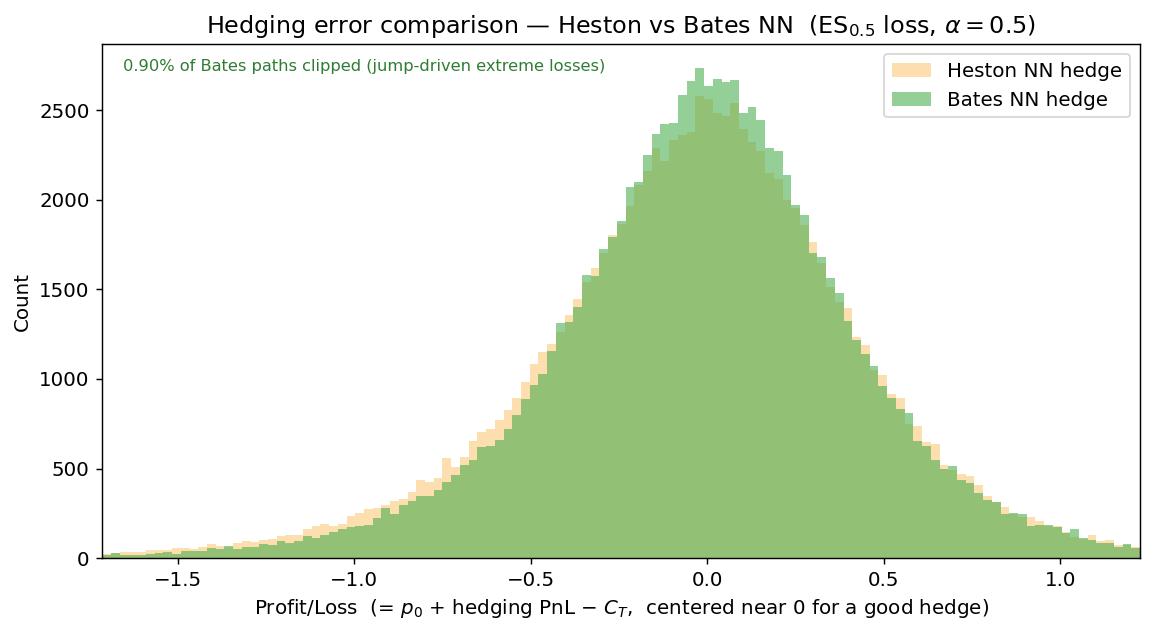

In [49]:
arr_h = pl_heston.numpy()
arr_b = pl_bates.numpy()

# Clip x-axis to 1st–99th percentile so rare jump outliers don't squash the bulk.
# (Bates can produce losses of -50 to -80 from large upward jumps that outpace
# the pre-set delta; those extreme paths are counted in the tail annotation below.)
lo = min(np.percentile(arr_h, 1.0), np.percentile(arr_b, 1.0))
hi = max(np.percentile(arr_h, 99.0), np.percentile(arr_b, 99.0))
margin = 0.05 * (hi - lo)
xlim   = (lo - margin, hi + margin)
bins   = np.linspace(*xlim, 120)

# Fraction of Bates paths outside the visible range (jump-driven extreme losses)
pct_clipped = 100 * (arr_b < xlim[0]).mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(arr_h, bins=bins, alpha=0.6, color='#FAC87A', label='Heston NN hedge')
ax.hist(arr_b, bins=bins, alpha=0.6, color='#4CAF50', label='Bates NN hedge')
ax.set_xlim(xlim)
ax.set_xlabel('Profit/Loss  (= $p_0$ + hedging PnL $-$ $C_T$,  centered near 0 for a good hedge)')
ax.set_ylabel('Count')
ax.set_title(f'Hedging error comparison — Heston vs Bates NN  (ES$_{{{ALPHA}}}$ loss, $\\alpha={ALPHA}$)')
ax.legend()
if pct_clipped > 0:
    ax.text(0.02, 0.97,
            f'{pct_clipped:.2f}% of Bates paths clipped (jump-driven extreme losses)',
            transform=ax.transAxes, va='top', fontsize=9, color='#2e7d32')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'heston_vs_bates_comparison.png', bbox_inches='tight')
plt.show()

## 5 — Summary statistics

In [50]:
var_levels = [0.99, 0.95, 0.90, 0.80, 0.50]
header = f"{'Model':<24} {'Mean':>8}" + "".join(f"{'VaR'+str(int(v*100)):>10}" for v in var_levels)
print(header)
print('-' * len(header))

for label, arr in [('Heston NN hedge', arr_h), ('Bates NN hedge', arr_b)]:
    qs  = [np.quantile(arr, 1 - v) for v in var_levels]
    row = f"{label:<24} {arr.mean():>8.4f}" + "".join(f"{q:>10.4f}" for q in qs)
    print(row)

Model                        Mean     VaR99     VaR95     VaR90     VaR80     VaR50
-----------------------------------------------------------------------------------
Heston NN hedge           -0.0312   -1.3818   -0.8371   -0.6084   -0.3749   -0.0092
Bates NN hedge            -0.0946   -1.5797   -0.7942   -0.5599   -0.3404   -0.0015


---
## 6 — Adversarial Training Comparison (Calibrated Heston)

Two networks trained on 100 K calibrated Heston paths with identical total epochs (700):

| Method | Epochs | Attack in training |
|--------|--------|--------------------|
| Clean | 700 clean | none |
| SV-Attack | 300 clean + 400 adv | perturb S and V jointly (δ = 0.005) |

Both are evaluated on the **same** calibrated Heston test paths (seed = 20).

In [179]:
from functools import partial
from src.hedging.adv_trainer import s_budget_attack, sv_budget_attack, train_adv_heston as _train_adv

def _auto_device():
    if torch.cuda.is_available():   return torch.device('cuda')
    if torch.backends.mps.is_available(): return torch.device('mps')
    return torch.device('cpu')

DEVICE = _auto_device()
print(f'Device: {DEVICE}')

# Simulate calibrated Heston training paths (same seed as Section 1)
# Re-simulated here so this section runs independently even when cached weights exist.
print('Simulating calibrated Heston training paths (seed=19) ...')
S_h_tr, V_h_tr, VP_h_tr = heston_simulate(heston_calib_params, seed=19)
VP_h_tr_scaled = VP_h_tr * vp_scale_heston
print(f'  Paths: {S_h_tr.shape},  vp_scale: {vp_scale_heston:.2f}')

# Call-price warm-start
with torch.no_grad():
    p0_h_init = float(torch.clamp(S_h_tr[:, -1] - K, min=0.0).mean())
print(f'  p0 warm-start: {p0_h_init:.4f}')

Device: mps
Simulating calibrated Heston training paths (seed=19) ...
  Paths: torch.Size([100000, 31]),  vp_scale: 185.67
  p0 warm-start: 2.9002


In [180]:
# Partial attack functions — keyword-only args pre-filled with calibrated Heston params.
# train_adv_heston calls: attack_fn(net, S_batch, V_batch) → (S_att, V_att, VP_att)
_atk_common = dict(
    K          = K,
    alpha_cvar = ALPHA,
    kappa      = heston_calib_params.kappa,
    theta      = heston_calib_params.theta,
    T          = heston_calib_params.T,
    N_steps    = N,
    VP_scale   = vp_scale_heston,   # same scale used in training
    ratio      = 4.0,
    iters      = 5,                 # attack steps per mini-batch (matches He et al.)
)
s_atk_fn  = partial(s_budget_attack,  delta=0.01,  **_atk_common)
sv_atk_fn = partial(sv_budget_attack, delta=0.01, **_atk_common)

# Common training kwargs shared across all three methods
_train_kwargs = dict(
    loss_fn    = HestonCVaRLoss(K=K, alpha=ALPHA),
    n_clean    = 300,
    n_adv      = 400,
    batch_size = 10_000,
    lr         = 5e-3,
    alpha_bal  = 0.0,   # pure adversarial loss in adv phase (He et al. N=100K optimal)
    atk_ratio  = 4.0,
    atk_n      = 5,
    p0_init    = p0_h_init,
    device     = DEVICE,
)

ADV_PATHS = {
    'clean': (RESULTS_DIR / 'heston_bates_adv_clean_network.pt',
              RESULTS_DIR / 'heston_bates_adv_clean_p0.pt'),
    'SV':    (RESULTS_DIR / 'heston_bates_adv_sv_network.pt',
              RESULTS_DIR / 'heston_bates_adv_sv_p0.pt'),
}
ADV_ATK_FNS = {'clean': None, 'SV': sv_atk_fn}
ADV_LABELS  = {'clean': 'Clean', 'SV': 'SV-Attack'}
ADV_COLORS  = {'clean': '#5B9BD5', 'SV': '#4CAF50'}

In [181]:
adv_nets = {}
adv_p0s  = {}

for method in ('clean', 'SV'):
    net_path, p0_path = ADV_PATHS[method]

    if net_path.exists():
        print(f'[{method}] Loading cached weights ...')
        net = HestonHedgeNet(N=N, width=20)
        net.load_state_dict(torch.load(net_path, weights_only=True))
        net.eval()
        adv_nets[method] = net
        adv_p0s[method]  = torch.load(p0_path, weights_only=True).item()
        print(f'  p0 = {adv_p0s[method]:.4f}')
    else:
        print(f'[{method}] Training ({_train_kwargs["n_clean"]} clean + '
              f'{_train_kwargs["n_adv"]} adv epochs) ...')
        net, p0 = _train_adv(
            S_h_tr.to(DEVICE),
            V_h_tr.to(DEVICE),
            VP_h_tr_scaled.to(DEVICE),
            ADV_ATK_FNS[method],
            desc=ADV_LABELS[method],
            **_train_kwargs,
        )
        net.eval()
        adv_nets[method] = net
        adv_p0s[method]  = p0

        torch.save(net.state_dict(), net_path)
        torch.save(torch.tensor(p0), p0_path)
        print(f'  Saved.  p0 = {p0:.4f}')

[clean] Loading cached weights ...
  p0 = 2.8813
[SV] Loading cached weights ...
  p0 = 2.8801


In [182]:
# Evaluate both on the SAME calibrated Heston test paths (seed=20, already computed)
adv_pls = {}
for method in ('clean', 'SV'):
    pl = compute_pl(adv_nets[method], S_h_test, V_h_test, VP_h_test_scaled, adv_p0s[method])
    adv_pls[method] = pl.numpy()
    pl_stats(pl, ADV_LABELS[method])

Clean                     mean=-0.0298  VaR99=-1.3801  VaR95=-0.8337  VaR90=-0.6050  VaR80=-0.3707  VaR50=-0.0095
SV-Attack                 mean=-0.0311  VaR99=-1.3768  VaR95=-0.8358  VaR90=-0.6080  VaR80=-0.3756  VaR50=-0.0115


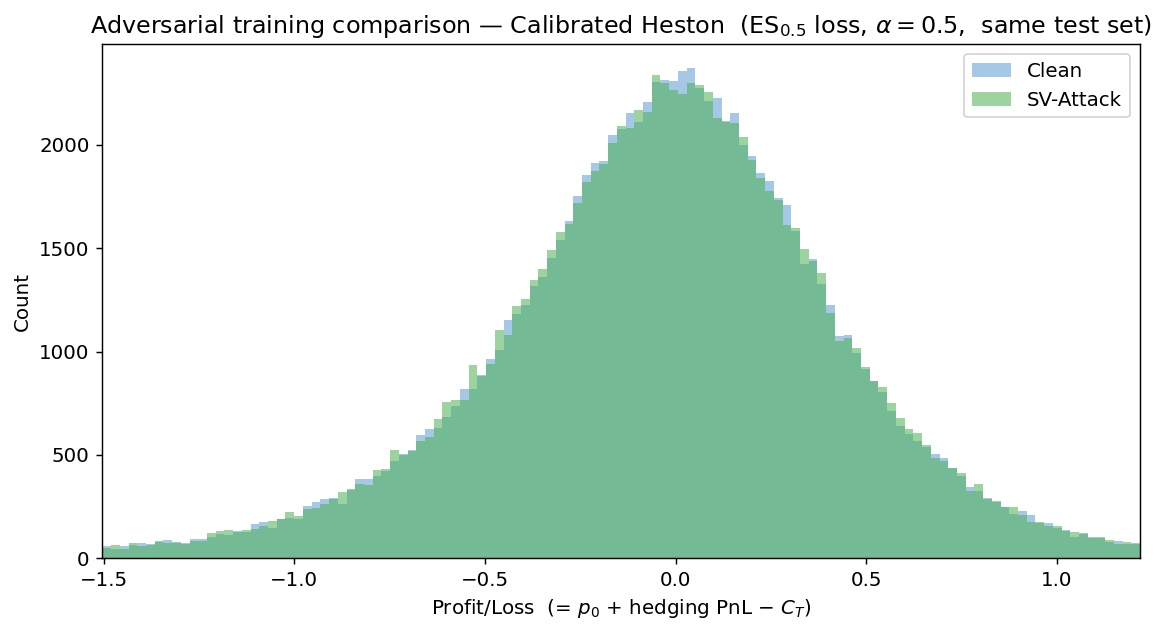

In [183]:
arrs = [adv_pls[m] for m in ('clean', 'SV')]

lo = min(np.percentile(a, 1.0) for a in arrs)
hi = max(np.percentile(a, 99.0) for a in arrs)
margin = 0.05 * (hi - lo)
xlim = (lo - margin, hi + margin)
bins = np.linspace(*xlim, 120)

fig, ax = plt.subplots(figsize=(9, 5))
for method in ('clean', 'SV'):
    ax.hist(adv_pls[method], bins=bins, alpha=0.55,
            color=ADV_COLORS[method], label=ADV_LABELS[method])

ax.set_xlim(xlim)
ax.set_xlabel('Profit/Loss  (= $p_0$ + hedging PnL $-$ $C_T$)')
ax.set_ylabel('Count')
ax.set_title(f'Adversarial training comparison — Calibrated Heston  '
             f'(ES$_{{{ALPHA}}}$ loss, $\\alpha={ALPHA}$,  same test set)')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'heston_calib_adv_comparison.png', bbox_inches='tight')
plt.show()

In [184]:
var_levels = [0.99, 0.95, 0.90, 0.80, 0.50]
header = f"{'Method':<14} {'Mean':>8}" + "".join(f"{'VaR'+str(int(v*100)):>10}" for v in var_levels)
print(header)
print('-' * len(header))
for method in ('clean', 'SV'):
    arr = adv_pls[method]
    qs  = [np.quantile(arr, 1 - v) for v in var_levels]
    print(f"{ADV_LABELS[method]:<14} {arr.mean():>8.4f}" + "".join(f"{q:>10.4f}" for q in qs))

Method             Mean     VaR99     VaR95     VaR90     VaR80     VaR50
-------------------------------------------------------------------------
Clean           -0.0298   -1.3801   -0.8337   -0.6050   -0.3707   -0.0095
SV-Attack       -0.0311   -1.3768   -0.8358   -0.6080   -0.3756   -0.0115


### 6b — Adversarial robustness validation

To confirm adversarial training worked, each network is evaluated under its own attack (iters=20, paper evaluation quality vs iters=5 during training). The expected pattern:

- **Clean** network degrades the most under both attacks
- **SV-Attack** network degrades the least under the SV-attack

Uses 10 K Heston test paths (attacking 100 K with iters=20 is prohibitively slow).

In [185]:
M_ATK_EVAL = 10_000

_atk_eval  = {**_atk_common, 'iters': 20}
s_eval_fn  = partial(s_budget_attack,  delta=0.01, **_atk_eval)
sv_eval_fn = partial(sv_budget_attack, delta=0.01, **_atk_eval)

def es_half_loss(arr):
    """ES_0.5 as a positive loss: mean of the worst 50% of P&L (most negative half), negated."""
    k = len(arr) // 2
    return float(-np.partition(arr, k)[:k].mean())

# Reload networks fresh from disk — MPS leaves BatchNorm running buffers in an
# inconsistent placeholder state after training + .cpu(), which crashes BatchNorm
# in eval mode.  torch.load always gives clean CPU-resident tensors.
eval_nets = {}
for method in ('clean', 'SV'):
    net_path, _ = ADV_PATHS[method]
    n = HestonHedgeNet(N=N, width=20)
    n.load_state_dict(torch.load(net_path, weights_only=True))
    n.eval()
    eval_nets[method] = n

rob = {}

S_ev  = S_h_test[:M_ATK_EVAL]
V_ev  = V_h_test[:M_ATK_EVAL]
VP_ev = VP_h_test_scaled[:M_ATK_EVAL]

for method in ('clean', 'SV'):
    net = eval_nets[method]   # clean CPU copy
    p0  = adv_p0s[method]
    row = {}

    # ── no attack
    pl = compute_pl(net, S_ev, V_ev, VP_ev, p0)
    row['no_atk'] = es_half_loss(pl.numpy())

    # ── S-attack: move to DEVICE in train() for BatchNorm batch stats, then back to CPU
    net.to(DEVICE).train()
    S_a, V_a, VP_a = s_eval_fn(net, S_ev.to(DEVICE), V_ev.to(DEVICE))
    net.cpu().eval()
    pl = compute_pl(net, S_a.cpu(), V_a.cpu(), VP_a.cpu(), p0)
    row['s_atk'] = es_half_loss(pl.numpy())

    # ── SV-attack
    net.to(DEVICE).train()
    S_a, V_a, VP_a = sv_eval_fn(net, S_ev.to(DEVICE), V_ev.to(DEVICE))
    net.cpu().eval()
    pl = compute_pl(net, S_a.cpu(), V_a.cpu(), VP_a.cpu(), p0)
    row['sv_atk'] = es_half_loss(pl.numpy())

    rob[method] = row

print(f"{'Network':<12}  {'No attack':>12}  {'S-attacked':>12}  {'SV-attacked':>12}  "
      f"{'Δ(S-atk)':>10}  {'Δ(SV-atk)':>10}")
print('-' * 78)
for method in ('clean', 'SV'):
    r  = rob[method]
    ds = r['s_atk']  - r['no_atk']
    dv = r['sv_atk'] - r['no_atk']
    print(f"{ADV_LABELS[method]:<12}  {r['no_atk']:>12.4f}  {r['s_atk']:>12.4f}  "
          f"{r['sv_atk']:>12.4f}  {ds:>+10.4f}  {dv:>+10.4f}")
print()
print("ES_0.5 as a loss (positive = worse).  Δ = degradation vs no-attack baseline.")
print("Smaller Δ = more robust to that attack type.")

Network          No attack    S-attacked   SV-attacked    Δ(S-atk)   Δ(SV-atk)
------------------------------------------------------------------------------
Clean               0.3895        0.4356        0.4416     +0.0461     +0.0521
SV-Attack           0.3926        0.4376        0.4424     +0.0450     +0.0498

ES_0.5 as a loss (positive = worse).  Δ = degradation vs no-attack baseline.
Smaller Δ = more robust to that attack type.


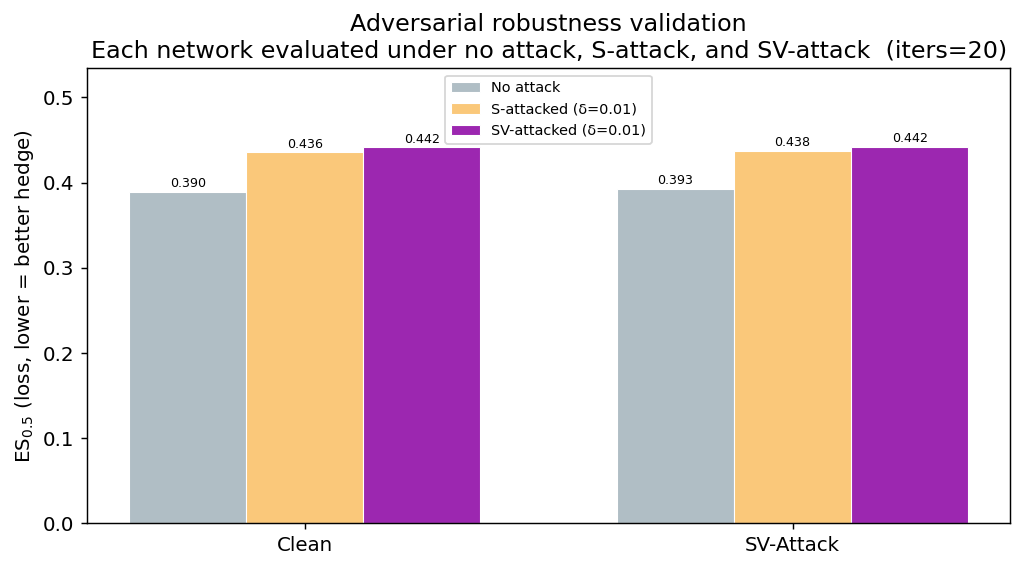

In [186]:
scenarios  = ['no_atk', 's_atk', 'sv_atk']
scen_labels = ['No attack', 'S-attacked (δ=0.01)', 'SV-attacked (δ=0.01)']
scen_colors = ['#B0BEC5', '#FAC87A', '#9C27B0']

x      = np.arange(len(ADV_LABELS))
width  = 0.24
fig, ax = plt.subplots(figsize=(8, 4.5))

for i, (scen, slabel, scolor) in enumerate(zip(scenarios, scen_labels, scen_colors)):
    vals = [rob[m][scen] for m in ('clean', 'SV')]
    bars = ax.bar(x + (i - 1) * width, vals, width, label=slabel,
                  color=scolor, edgecolor='white', linewidth=0.6)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.002,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(list(ADV_LABELS.values()))
ax.set_ylabel('ES$_{0.5}$ (loss, lower = better hedge)')
ax.set_title('Adversarial robustness validation\n'
             'Each network evaluated under no attack, S-attack, and SV-attack  (iters=20)')
ax.legend(fontsize=8)
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'adv_robustness_validation.png', bbox_inches='tight')
plt.show()

---
## 7 — Cross-Model Robustness: Heston Networks Tested on Bates

Both Heston-trained networks (Clean, SV-Attack) are evaluated on the **Bates test paths** alongside the Bates-trained network as the in-distribution benchmark.

This measures **model risk**: a trader who trains and prices with Heston but faces a market that actually follows Bates dynamics (with jumps). Key questions:
- How much does the distribution widen relative to the Bates benchmark?
- Does adversarial training on Heston transfer any robustness to Bates jump risk?

**VP scaling note**: the Heston networks expect VarPrice scaled by `vp_scale_heston`.  
Bates VarPrice is re-scaled by `vp_scale_heston` (not `vp_scale_bates`) before being fed to the Heston networks, so the network sees the same input magnitude it was trained on.

In [187]:
# Bates VarPrice re-scaled with the HESTON scale factor so Heston networks see the
# same input magnitude they were trained on.  VP_b_test is the raw (unscaled) tensor
# produced in Section 3 (comp-bates-eval).
VP_b_for_heston = VP_b_test * vp_scale_heston

# Each Heston network uses its own learned p0 (Heston call price ≈ 3.x).
# This reflects what a trader would actually do: price with Heston, hedge with Heston,
# but face Bates dynamics — model mispricing is included in the P&L.
cross_pls = {}
for method in ('clean', 'SV'):
    pl = compute_pl(adv_nets[method], S_b_test, V_b_test, VP_b_for_heston, adv_p0s[method])
    cross_pls[method] = pl.numpy()

# Bates benchmark: already computed in Section 3 — in-distribution performance
cross_pls['bates'] = pl_bates.numpy()

CROSS_LABELS = {'clean': 'Heston Clean',
                'SV': 'Heston SV-Attack', 'bates': 'Bates NN (benchmark)'}
CROSS_COLORS = {'clean': '#5B9BD5',
                'SV': '#9C27B0',    'bates': '#4CAF50'}

for method in ('clean', 'SV', 'bates'):
    pl_stats(torch.tensor(cross_pls[method]), CROSS_LABELS[method])

Heston Clean              mean=0.0565  VaR99=-11.0711  VaR95=-7.4690  VaR90=-5.7340  VaR80=-3.6952  VaR50=0.1181
Heston SV-Attack          mean=0.0653  VaR99=-6.3104  VaR95=-4.0644  VaR90=-3.0526  VaR80=-1.9026  VaR50=0.1958
Bates NN (benchmark)      mean=-0.0946  VaR99=-1.5797  VaR95=-0.7942  VaR90=-0.5599  VaR80=-0.3404  VaR50=-0.0015


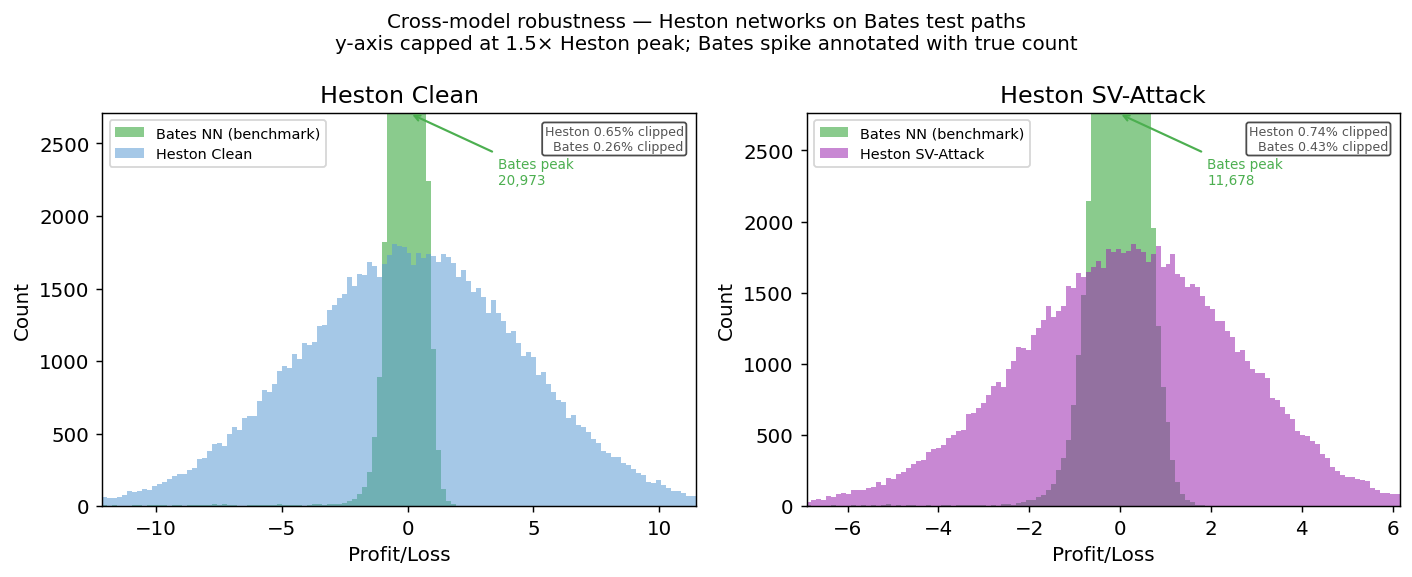

In [188]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
methods_plot = ('clean', 'SV')

for ax, method in zip(axes, methods_plot):
    arr_h = cross_pls[method]
    arr_b = cross_pls['bates']

    # x-axis: 1st–99th percentile of the Heston network (so its shape is visible)
    lo = np.percentile(arr_h, 1.0)
    hi = np.percentile(arr_h, 99.0)
    margin = 0.05 * (hi - lo)
    xlim = (lo - margin, hi + margin)
    bins = np.linspace(*xlim, 120)

    # Draw Bates first (background), then Heston on top
    b_counts, _, _ = ax.hist(arr_b, bins=bins, alpha=0.65,
                              color=CROSS_COLORS['bates'], label='Bates NN (benchmark)')
    h_counts, _, _ = ax.hist(arr_h, bins=bins, alpha=0.55,
                              color=CROSS_COLORS[method], label=CROSS_LABELS[method])

    # Cap y-axis at 1.5× the Heston peak so its shape is fully visible.
    # The Bates spike exceeds this cap and is annotated with its true height.
    y_cap = max(h_counts) * 1.5
    ax.set_ylim(0, y_cap)

    bates_peak = int(b_counts.max())
    if bates_peak > y_cap:
        # Mark where the Bates spike is clipped with an arrow + label
        peak_bin_centre = bins[b_counts.argmax()] + 0.5 * (bins[1] - bins[0])
        ax.annotate(f'Bates peak\n{bates_peak:,}',
                    xy=(peak_bin_centre, y_cap),
                    xytext=(peak_bin_centre + 0.15*(xlim[1]-xlim[0]), y_cap * 0.82),
                    fontsize=7.5, color=CROSS_COLORS['bates'],
                    arrowprops=dict(arrowstyle='->', color=CROSS_COLORS['bates'], lw=1.2))

    ax.set_xlim(xlim)
    ax.set_xlabel('Profit/Loss')
    ax.set_ylabel('Count')
    ax.set_title(CROSS_LABELS[method])
    ax.legend(fontsize=8, loc='upper left')

    # Clipping stats
    pct_h = 100 * (arr_h < xlim[0]).mean()
    pct_b = 100 * (arr_b < xlim[0]).mean()
    ax.text(0.98, 0.97,
            f'Heston {pct_h:.2f}% clipped\nBates {pct_b:.2f}% clipped',
            transform=ax.transAxes, va='top', ha='right',
            fontsize=7, color='#555555',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

fig.suptitle('Cross-model robustness — Heston networks on Bates test paths\n'
             'y-axis capped at 1.5× Heston peak; Bates spike annotated with true count',
             fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cross_model_robustness.png', bbox_inches='tight')
plt.show()

In [189]:
var_levels = [0.99, 0.95, 0.90, 0.50]
header = f"{'Network':<22} {'Mean':>8}" + "".join(f"{'VaR'+str(int(v*100)):>10}" for v in var_levels) + f"{'ΔVAR99':>10}"
sep = '-' * len(header)
print(header)
print(sep)

bates_var99 = np.quantile(cross_pls['bates'], 0.01)
for method in ('bates', 'clean', 'SV'):
    arr  = cross_pls[method]
    qs   = [np.quantile(arr, 1 - v) for v in var_levels]
    dvar = '' if method == 'bates' else f'{qs[0] - bates_var99:>+10.2f}'
    print(f"{CROSS_LABELS[method]:<22} {arr.mean():>8.4f}" + "".join(f"{q:>10.4f}" for q in qs) + dvar)

Network                    Mean     VaR99     VaR95     VaR90     VaR50    ΔVAR99
---------------------------------------------------------------------------------
Bates NN (benchmark)    -0.0946   -1.5797   -0.7942   -0.5599   -0.0015
Heston Clean             0.0565  -11.0711   -7.4690   -5.7340    0.1181     -9.49
Heston SV-Attack         0.0653   -6.3104   -4.0644   -3.0526    0.1958     -4.73
